In [163]:
import numpy as np
import pandas as pd
import random
import time
from rapidfuzz import process, fuzz, distance
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spoa 
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import HDBSCAN
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

# --- 2. DATA GENERATION & UTILS ---
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# (Generating fresh data to ensure variables exist for the loop below)
n_items = 20_000 
pool_bc = [gen_dna(12) for _ in range(n_items)]
pool_ins = [gen_dna(40) for _ in range(n_items)]
n_repeat_bc = 500
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]

data = []
for i in range(len(pool_bc)):
     n_reads = random.randint(3, 6) 
     for _ in range(n_reads):
         data.append({
             "ID": i,
             "Barcode": mutate_sequence(pool_bc[i], 0.1), 
             "Insert": mutate_sequence(pool_ins[i], 0.1)
         })

df = pd.DataFrame(data)

In [321]:
def encode_msa(msa_strings, alphabet="ACGTN-"):
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    max_len = max(len(s) for s in msa_strings)
    msa_padded = [s.ljust(max_len, '-') for s in msa_strings]
    msa_array = np.array([list(seq) for seq in msa_padded])
    N, L = msa_array.shape
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
    return msa_int, len(alphabet)


def get_marginals(msa_int, vocab_size):
    # Create on hot matrix
    one_hot = np.eye(vocab_size)[msa_int]
    # Calculate frequencies of each base/N/- at each position in MSA
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """
    Compute mutual information scores in the MSA
    """
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))


def get_elbow_columns(mi_matrix, exclusion_distance=5, verbose=0):
    L = mi_matrix.shape[0]
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]
    
    if len(scores) == 0: return np.array([])

    # 1. Sort Descending
    sorted_indices = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_indices]
    
    # 2. Determine "Signal End" (Noise Floor Truncation)
    # We stop analyzing where the score drops below the bottom 25% percentile
    noise_floor = np.percentile(scores, 25)
    
    # Keep points strictly ABOVE noise floor for the shape analysis
    # (But keep at least 5 points to allow for geometry, unless total is small)
    valid_mask = sorted_scores > noise_floor
    n_signal_points = np.sum(valid_mask)
    
    # Safety: if signal is super short, take at least top 10% or min 5
    min_points = min(len(sorted_scores), 5)
    cutoff_idx = max(n_signal_points, min_points)
    
    # 3. Truncate for Geometry Calculation
    # We only look for the elbow within the "Signal" region
    curve_y = sorted_scores[:cutoff_idx]
    n_points = len(curve_y)
    
    if n_points < 3:
        # Fallback for tiny signals
        return np.unique(np.concatenate([rows[sorted_indices[:n_points]], cols[sorted_indices[:n_points]]]))

    # 4. Standard Kneedle on Truncated Curve
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (curve_y - curve_y.min()) / (curve_y.max() - curve_y.min() + 1e-9)
    
    # Line from First Point (0, 1) to Last Signal Point (1, 0)
    line_vec = np.array([1.0, -1.0]) # Direction vector (x=1-0, y=0-1)
    line_vec = line_vec / np.linalg.norm(line_vec)
    
    # Vectors from start (0, 1) to all points
    vec_from_start = np.stack([x_norm, y_norm - 1.0], axis=1)
    
    # Cross product (2D) to find distance
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])
    
    # 5. Select
    elbow_idx = np.argmax(distances)
    
    # If the plateau is perfectly flat, elbow_idx might be 0. 
    # In that case, we likely want the whole plateau, not just index 0.
    # We check if the point at elbow_idx is significantly higher than end.
    if elbow_idx == 0:
        # Heuristic: If index 0 is picked, but index 1 is very close in value, walk forward
        # This handles the "perfect plateau" case
        for i in range(1, n_points - 1):
            if curve_y[i] >= (curve_y[0] * 0.95): # Still within 5% of max
                elbow_idx = i
            else:
                break

    n_selected = elbow_idx + 1 # +1 because index is 0-based
    
    # --- Debug Plot (Only if Verbose) ---
    if verbose >= 3:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 3))
        plt.plot(range(n_points), curve_y, '-o', markersize=3, label='Signal Curve')
        plt.axvline(elbow_idx, color='r', linestyle='--', label=f'Elbow (k={n_selected})')
        plt.axhline(noise_floor, color='k', linestyle=':', alpha=0.5, label='Noise Floor')
        plt.title(f"Elbow Analysis (Selecting {n_selected} cols)")
        plt.legend()
        plt.show()

    selected_indices = sorted_indices[:n_selected]

    selected_columns = np.unique(np.concatenate([rows[selected_indices], cols[selected_indices]]))
    
    if verbose >= 3:
        print(f"selected MSA columns: {selected_columns}")
    return selected_columns


def calculate_msa_mi_and_top_cols(barcodes, inserts, verbose=0, mi_exclusion_distance=3):
    
    _, msa_barcodes = spoa.poa(barcodes, algorithm=2) 
    _, msa_inserts = spoa.poa(inserts, algorithm=2)
    msa_strings = [b + "--------" + i for b, i in zip(msa_barcodes, msa_inserts)]

    # Encode MSA into a numpy array with numbers (should be treated as categoricals)
    msa_int, vocab_size = encode_msa(msa_strings)

    # Create one hot matrix and the frequencies of each base at each position in MSA
    one_hot, P_i = get_marginals(msa_int, vocab_size)
    
    # Calculate mutual information scores in MSA
    mi_matrix = compute_mi_scores(one_hot, P_i)

    # Use elbow approach to find pairs in MSA with high mutual information
    # Exclude very close positions as sequencing errors of more than one base may 
    # produce spurious mutual info
    top_cols = get_elbow_columns(mi_matrix, mi_exclusion_distance, verbose=verbose)    

    return msa_int, mi_matrix, top_cols


from sklearn.metrics import pairwise_distances
from sklearn.cluster import SpectralClustering
import numpy as np

def cluster_msa_subset_with_HDBSCAN(msa_subset, expected_error_rate, never_link=3):
    # Compute Hamming distance matrix
    dist_matrix = pairwise_distances(msa_subset, metric='hamming')

    # --- Primary method: HDBSCAN ---
    hdb = HDBSCAN(
        metric='precomputed',
        min_cluster_size=2,
        min_samples=1,
        cluster_selection_method='leaf'
    )

    labels = hdb.fit_predict(dist_matrix)

    # Check if HDBSCAN failed
    # Conditions: all noise (-1), or only one cluster label
    unique_labels = list(set(labels))

    print(f"AAAHHHHH {unique_labels}")

    if len(unique_labels) == 1 and unique_labels[0] == -1:  # then HDBSCAN just found noise
        # --- Fallback: Spectral Clustering ---
        # Use similarity matrix (Spectral needs affinities, not distances)
        sim_matrix = 1.0 - dist_matrix

        # Decide number of clusters:
        # If HDBSCAN found none: guess based on silhouette-like heuristic
        # Minimum: 2 clusters
        # n_clusters = max(2, min(msa_subset.shape[0] // 2, 5))
        n_clusters = 2

        spectral = SpectralClustering(
            affinity='precomputed',
            n_clusters=n_clusters,
            assign_labels='discretize'
        )

        labels = spectral.fit_predict(sim_matrix)

        print("SPECTRAL")
        print(labels)

    return dist_matrix, labels



def cluster_barcode_insert_pairs(barcodes, inserts, mi_exclusion_distance, expected_error_rate, verbose=0):
    
    # Produce integer-encoded msa, mutual information matrix and identify most informative columns
    msa_int, mi_matrix, top_cols = calculate_msa_mi_and_top_cols(barcodes, inserts, verbose, mi_exclusion_distance)

    # Get just the most informative (i.e., highest mutual information) columns of MSA
    msa_subset = msa_int[:, top_cols]

    # Identify rough clusters using HDBSCAN
    dist_matrix, labels = cluster_msa_subset_with_HDBSCAN(msa_subset, expected_error_rate)

    return msa_int, mi_matrix, msa_subset, dist_matrix, labels


def plot_confusion_matrix(labels, real_IDs):
    from sklearn.metrics.cluster import contingency_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # 1. Compute the contingency matrix
    # This counts the overlap between every unique value in labels vs real_IDs
    cont_mat = contingency_matrix(labels, real_IDs)
    
    # 2. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(cont_mat, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Real IDs (Arbitrary)")
    plt.ylabel("Predicted Labels (Arbitrary)")
    plt.title("Contingency Matrix (Unsorted)")
    plt.show()

def get_poa_consensus(barcode_series):
    """
    Function to call the POA alignment on a Series of Barcode strings.
    
    Args:
        barcode_series (pd.Series): A Series containing all Barcodes for a single cluster.
        
    Returns:
        tuple: (consensus_sequence, multiple_sequence_alignment)
    """
    # Convert the pandas Series of barcodes to a standard Python list
    barcode_list = barcode_series.tolist()
    
    # Call the external POA function
    consensus, _ = spoa.poa(barcode_list, algorithm=2)
    
    return consensus # We will return just the consensus sequence for simplicity in this example


def recursive_hamming_driver(sub_df, all_df, barcode_target, percentile_th, expected_error_rate, 
                             verbose=0, mi_exclusion_distance=3, cluster_again_total_mean_thresh=2,
                             cluster_again_single_mean_thresh=3):

    if len(sub_df) < 2:
        # Ensure consistency by assigning a default cluster if minimal size
        if 'cluster' not in sub_df.columns: sub_df = sub_df.copy(); sub_df['cluster'] = -1
        return sub_df

    
    # Create lists of all barcodes and inserts in sub_df
    barcodes = sub_df['Barcode'].tolist()
    inserts = sub_df['Insert'].tolist()
    
    # Process pairs
    msa_int, mi_matrix, msa_subset, dist_matrix, labels = cluster_barcode_insert_pairs(barcodes, 
                                                                                       inserts, 
                                                                                       mi_exclusion_distance,
                                                                                       expected_error_rate,
                                                                                       verbose=0)

    labels = labels + hash(frozenset(sub_df.index)) % 10_000_000

    print("\n================")
    print(sub_df)
    print(labels)
    print(dist_matrix)
    print(msa_subset)
    

    dfs = [] # Collection list for the final result chunks

    for label in list(set(labels)):
        # 1. Create the mask and subset immediately
        mask = np.array(labels) == label
        subset = sub_df[mask].copy()

        if label == -1:
            # Noise is final; assign label and append
            subset['cluster'] = -1
            dfs.append(subset)
            continue 
            
        # 2. Filter the distance matrix using the mask for both axes
        filtered_dist_matrix = dist_matrix[mask][:, mask]

        # Check Impurity Conditions
        mean_dist = np.mean(filtered_dist_matrix)
        row_means = np.mean(filtered_dist_matrix, axis=1)
        
        # If impure, RECURSE
        if (mean_dist > cluster_again_total_mean_thresh * expected_error_rate) or \
           (max(row_means) > cluster_again_single_mean_thresh * expected_error_rate):
            
            print(f"Recursing on label {label}...")
            # Recursive call on the subset
            recursive_result = recursive_hamming_driver(subset, all_df, barcode_target, percentile_th, 
                                                        expected_error_rate, verbose, mi_exclusion_distance, 
                                                        cluster_again_total_mean_thresh, cluster_again_single_mean_thresh)
            dfs.append(recursive_result)
        
        # If pure, KEEP
        else:
            subset['cluster'] = label
            dfs.append(subset)

    result = pd.concat(dfs)
    
    # Re-normalise cluster labels to 0,1,2,... but KEEP -1 as noise
    unique = [u for u in sorted(result['cluster'].unique()) if u != -1]
    mapping = {old: new for new, old in enumerate(unique)}
    result['cluster'] = result['cluster'].map(lambda x: mapping.get(x, -1))
    
    return result

# def iterative_hamming_driver(sub_df, all_df, barcode_target, percentile_th, expected_error_rate, 
#                              verbose=0, mi_exclusion_distance=3, cluster_again_total_mean_thresh=2,
#                             cluster_again_single_mean_thresh=3):

#     if len(sub_df) < 2:
#         return sub_df


    
#     # Create lists of all barcodes and inserts in sub_df (i.e., with similar barcode)
#     # and create MSAs separately, then merge with a spacer
    
#     barcodes = sub_df['Barcode'].tolist()
#     inserts = sub_df['Insert'].tolist()
    
#     # Process pairs
#     msa_int, mi_matrix, msa_subset, dist_matrix, labels = cluster_barcode_insert_pairs(barcodes, 
#                                                                                        inserts, 
#                                                                                        mi_exclusion_distance,
#                                                                                        expected_error_rate,
#                                                                                        verbose=0)

#     to_recluster = set()
#     for label in list(set(labels)):
#         if label == -1:
#             continue  # already flagged as noise
            
#         # 1. Create the boolean mask
#         print(label)
#         mask = np.array(labels) == label
        
#         # 2. Filter the distance matrix using the mask for both axes
#         filtered_dist_matrix = dist_matrix[mask][:, mask]

#         print(filtered_dist_matrix)

#         # If mean distances within a cluster are much higher than expected error rate,
#         # this suggests that the cluster is impure
#         mean_dist = np.mean(filtered_dist_matrix)
#         if mean_dist > cluster_again_total_mean_thresh * expected_error_rate:
#             to_recluster.add(label)
#             continue

#         # Or, if a single (or more) example have a very high distance to the others on average, again
#         # this suggests impurity
#         row_means = np.mean(filtered_dist_matrix, axis=1)
#         if max(row_means) > cluster_again_single_mean_thresh * expected_error_rate:
#             to_recluster.add(label)
        
#     print(to_recluster)

#     # Add proposed labels to sub_df
#     sub_df['cluster'] = labels
    
#     if verbose >= 3:
#         plot_confusion_matrix(sub_df['cluster'], sub_df['ID'].tolist())

#     # Find consensus barcode of each cluster, and remove those that don't match target
#     sub_df['cluster_consensus_bc'] = sub_df.groupby('cluster')['Barcode'].transform(get_poa_consensus)
    
#     # 2. Apply the final combined filter on - either the consensus matches, or, if only 2 reads, at least 1 matches the target barcode perfectly
#     sub_df = sub_df[
#         (sub_df['cluster_consensus_bc'] == barcode_target) | # Mask A: Consensus matches target
#         ( (sub_df.groupby('cluster')['Barcode'].transform('size') == 2) & # Mask B part 1: Group size is 2
#           (sub_df.groupby('cluster')['Barcode'].transform(lambda x: (x == barcode_target).any())) # Mask B part 2: Group contains target
#         )
#     ]

#     # Get consensus insert
#     sub_df['cluster_consensus_insert'] = sub_df.groupby('cluster')['Insert'].transform(get_poa_consensus)


#     barcodes = sub_df['Barcode'].tolist()
#     inserts = sub_df['Insert'].tolist()
    
#     # Process pairs
#     msa_int, mi_matrix, msa_subset, dist_matrix, labels = cluster_barcode_insert_pairs(barcodes, 
#                                                                                        inserts, 
#                                                                                        mi_exclusion_distance, 
#                                                                                        expected_error_rate,
#                                                                                        verbose=0)

#     plt.figure(figsize=(8, 7)) # Adjust size as needed
#     sns.heatmap(dist_matrix, cmap='viridis') # 'viridis' is a good default colormap
#     plt.title("Distance Matrix Heatmap")
#     plt.show()
        


#     return sub_df

In [322]:
# ==== PARAMS =====

verbose = 3
percentile_th = 5
expected_error_rate = 0.1

# ==== RUN =====

barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

for i, (top_bc, count) in enumerate(barcode_counts.head(1).items()):

    if verbose >= 1:
        print(f"Processing Top Barcode #{i+1}: {top_bc} (Count: {count})")

    # top_bc = "TATCATGGCAGC" # Force specific barcode if needed for debug
    
    # RapidFuzz
    scores = process.cdist([top_bc], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    candidate_bcs = all_barcodes[np.where(scores > 85)[0]]
    filtered_df = df[df['Barcode'].isin(candidate_bcs)].copy()

    # filtered_df = pd.read_csv("~/Downloads/fml.csv")
    print(filtered_df)

    if filtered_df.empty: continue

    if verbose >= 2:
        print(f"  > RapidFuzz gathered {len(filtered_df)} reads")

    result_df = recursive_hamming_driver(filtered_df, df, top_bc, 
                                          percentile_th=percentile_th, verbose=verbose, expected_error_rate=expected_error_rate)



Processing Top Barcode #1: TCGAAGGGATCT (Count: 10)
          ID        Barcode                                             Insert
1095     248   TCGAAGGGATCT         TGATCTATCGAGACCGATACAGTCTCACTCACAGGCCAATTG
1096     248    TCGAGGGATCT          GGATCAATCAGTCCGATTACAGTTCACTCACAGGCCAATTG
1097     248   TCGAAGGGATCT            GGATCAATCAGTCCGATACAGTTCACTCACAGGCAATTG
1098     248   TCGAAGGGATCT          GGATCAATCAGTCCTGATACAGTTCACTCACAGGCCAATTG
25590   5679    ACAAGGGATCT          GGAATCTACGGCTTTCGTTTGCTTAATTGGCACAAAGCAAG
29671   6582    CGAGGGATACT            CGCGCGGTGTCGGGGGATGGGGTAACACAAGGATCGGAA
30195   6698    ATGAGGGATCT         CTTGCAGAACGCTTTTCGTGTAATAGATAGTTAAATCTTTAT
41775   9268    TCGAGCGGACT          TGGCACTGCATTGTTACTCTGTGGTTCACAAACACTCTACC
63126  14021    TAAGGGATTCT           TCCTTCAGCTCTTGCCTGAAAGTGTGAAGTATTTGCGCAC
72421  16086    TGCGAAGATCT           CACCATCCACTTCTTACTCAGTGGCCTATGAACAAACGTG
78186  17362    TCGAAGGGACT          AGCCCGTTGTTGCATTTTCCCATCCACCCTGGCGCCCTCGC


/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silenc

In [320]:
result_df

,ID,Barcode,Insert,cluster
93311,20748,TCGAAGGGATCT,TTACGTTTTCCCAACCGGATCCTCATGCTCACTGACCCTGAGTCCACCG,0
93309,20748,TCGAAGGGATCT,TACGTTTTCCGAACCGGATCCTCATGCTCATAGACCCGAGTCCACCG,1
93310,20748,TCGAAGGGATCT,CTACGTTATCCGAACCGGATCCTCATGCTCACTAGCCTCTGAGTCC...,2
93308,20748,TCGAAGGGATCT,CTACGACTTCCGAACCGGATCCTCCATGCTACTATCACCCTGAGTC...,3
78186,17362,TCGAAGGGACT,AGCCCGTTGTTGCATTTTCCCATCCACCCTGGCGCCCTCGC,4
63126,14021,TAAGGGATTCT,TCCTTCAGCTCTTGCCTGAAAGTGTGAAGTATTTGCGCAC,5
91111,20248,TCGAAGGGATCT,TACGCACATGTGCCTCGCTGCGTTGTTTTCAAGTCCAATACCTAGC...,6
91112,20248,TCGAAGGGAATCT,TACGCACAGTGCCTCGCTGCTTGTTTTCAAGTCATTACCTAGAGACTC,6
91113,20248,TCGAAGGGATCT,TACGCACATGTGCCTACTTGCGTTGTTTTCAAGTCCATACCTAGGG...,6
91114,20248,TCGACAGGGATCT,TACGCACATGTGCCTCGCTGCGTTCTTTTCAAGTCCATACCAGGGACTC,6


--- Clustering Results (Labels Assigned) ---
Index: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
K-Means (K=3): [2 0 0 0 0 1 1]
Agglomerative (K=3): [0 0 0 0 0 2 1]
DBSCAN (eps=1, min_s=3): [0 0 0 0 0 0 0]
HDBSCAN (min_c=2, min_s=1): [-1 -1 -1 -1 -1 -1 -1]


/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


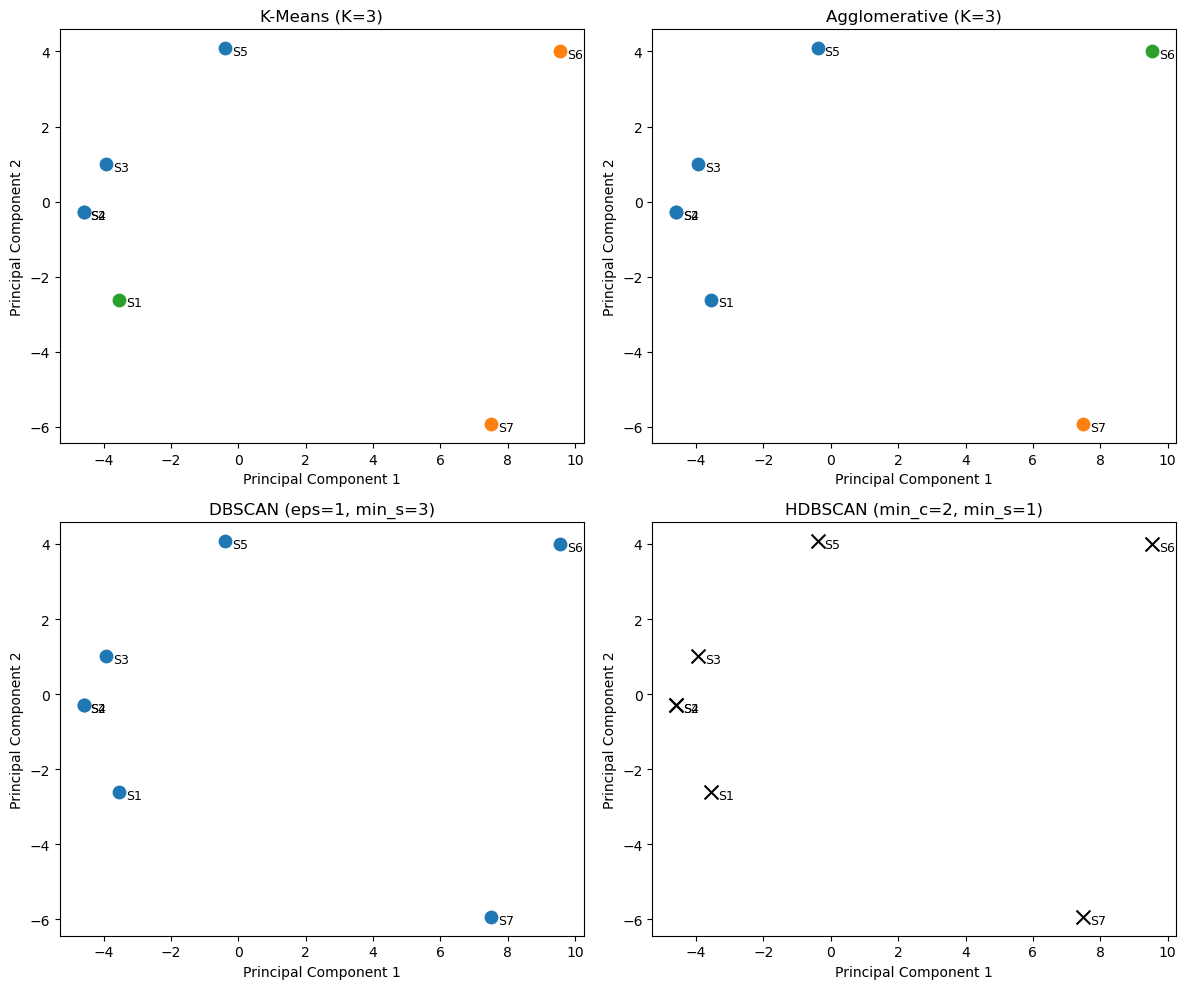

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.decomposition import PCA # Switched to PCA
from sklearn.metrics import pairwise_distances

# --- 1. Data Setup ---

# Your 7 inputs (sequences)
data = np.array([
    [3, 3, 2, 0, 3, 3, 0, 3, 1, 2, 0, 0, 1, 0, 0, 5, 5, 0, 1, 1, 3, 1, 1, 1, 3, 5, 5, 5], # S1
    [3, 2, 2, 0, 3, 0, 0, 3, 1, 5, 0, 3, 1, 0, 0, 5, 5, 0, 5, 1, 3, 1, 1, 1, 3, 5, 5, 5], # S2
    [3, 2, 2, 0, 3, 0, 0, 3, 1, 5, 0, 3, 1, 0, 0, 5, 5, 0, 5, 1, 3, 1, 5, 1, 3, 5, 5, 5], # S3
    [3, 2, 2, 0, 3, 0, 0, 3, 1, 5, 0, 3, 1, 0, 0, 5, 5, 0, 5, 1, 3, 1, 1, 1, 3, 5, 5, 5], # S4
    [0, 2, 2, 0, 3, 3, 0, 1, 2, 2, 1, 3, 1, 3, 2, 3, 3, 0, 5, 2, 0, 5, 5, 1, 5, 5, 5, 5], # S5
    [5, 5, 5, 5, 5, 1, 2, 1, 2, 2, 3, 3, 2, 2, 2, 3, 2, 2, 5, 0, 0, 5, 5, 5, 1, 2, 0, 0], # S6
    [0, 5, 5, 5, 5, 3, 3, 2, 1, 5, 0, 0, 2, 3, 3, 5, 5, 5, 2, 0, 0, 3, 3, 0, 1, 3, 3, 0]  # S7
], dtype=int)
sequence_names = [f'S{i+1}' for i in range(len(data))]
N_SEQUENCES = len(data)

# Calculate the Hamming distance matrix (still needed for distance-based clustering)
dist_matrix = pairwise_distances(data, metric='hamming')

# --- 2. Dimensionality Reduction for Plotting (PCA) ---

# PCA must be run on the raw data, not the distance matrix
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(data) # Fit on the raw data!


# --- 3. Clustering Algorithms and Parameter Selection ---

K = 3

clustering_algorithms = {
    # K-Means: Uses raw data, implicitly using Euclidean distance (PCA's native distance)
    "K-Means (K=3)": KMeans(n_clusters=K, random_state=42, n_init='auto', max_iter=1000),

    # Agglomerative: Uses pre-computed Hamming distance
    "Agglomerative (K=3)": AgglomerativeClustering(n_clusters=K, linkage='complete', metric='precomputed'),

    # DBSCAN: Uses pre-computed Hamming distance
    "DBSCAN (eps=1, min_s=3)": DBSCAN(eps=1, min_samples=3, metric='precomputed'),

    # HDBSCAN: Uses pre-computed Hamming distance
    "HDBSCAN (min_c=2, min_s=1)": HDBSCAN(min_cluster_size=2, min_samples=1, metric='precomputed'),
}

# --- 4. Plotting Function ---

def plot_clustering_results(X_plot, labels, ax, title, sequence_names):
    """Plots the PCA results colored by cluster labels."""
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # Handle Noise (-1) specially
    has_noise = -1 in unique_labels
    
    # Plot Noise first
    if has_noise:
        noise_mask = labels == -1
        ax.scatter(X_plot[noise_mask, 0], X_plot[noise_mask, 1], 
                   label='Noise (-1)', color='black', marker='x', s=100, zorder=10)
    
    # Plot Clusters
    for i, lab in enumerate(unique_labels):
        if lab == -1: continue
        mask = labels == lab
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], label=f'Cluster {lab}', s=80)
        
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    
    # Annotate points with sequence names
    for i, txt in enumerate(sequence_names):
        ax.annotate(txt, (X_plot[i, 0], X_plot[i, 1]), 
                    textcoords="offset points", xytext=(5,-5), ha='left', fontsize=9)

# --- 5. Execute and Plot ---

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plot_idx = 0

print("--- Clustering Results (Labels Assigned) ---")
print(f"Index: {sequence_names}")

for name, model in clustering_algorithms.items():
    # K-Means uses the raw data (Euclidean/default metric)
    if 'K-Means' in name:
        labels = model.fit_predict(data)
    
    # Others use the pre-computed Hamming distance matrix
    else:
        labels = model.fit_predict(dist_matrix)

    # Plotting
    plot_clustering_results(X_pca, labels, axes[plot_idx], name, sequence_names)
    plot_idx += 1
    
    # Print Labels
    print(f"{name}: {labels}")

plt.tight_layout()
plt.show()
print("\n")